# PCA — USA Cars Dataset
**Lead University · Minería de Datos · Tarea 3**

Análisis de Componentes Principales sobre el dataset de vehículos eléctricos.
Objetivo: entender qué factores definen la eficiencia y la autonomía en el plano principal.

In [11]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import PCAAnalysis

sns.set(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
print('Librerías cargadas.')

Librerías cargadas.


In [12]:
df = pd.read_csv('datos/USA_Cars_Dataset.csv')
print(f'Registros: {df.shape[0]} | Variables: {df.shape[1]}')
print(f'Marcas: {sorted(df["Brand"].unique())}')
df.head()

Registros: 53 | Variables: 14
Marcas: ['BMW', 'CHEVROLET', 'FORD', 'KIA', 'MITSUBISHI', 'NISSAN', 'SMART', 'TESLA']


,YEAR,Brand,Model,Size,(kW),CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),RATING,(km),TIME (h)
0,2012,MITSUBISHI,i-MiEV,SUBCOMPACT,49,16.9,21.4,18.7,1.9,2.4,2.1,8,100,7
1,2012,NISSAN,LEAF,MID-SIZE,80,19.3,23.0,21.1,2.2,2.6,2.4,3,117,7
2,2013,FORD,FOCUS ELECTRIC,COMPACT,107,19.0,21.1,20.0,2.1,2.4,2.2,9,122,4
3,2013,MITSUBISHI,i-MiEV,SUBCOMPACT,49,16.9,21.4,18.7,1.9,2.4,2.1,2,100,7
4,2013,NISSAN,LEAF,MID-SIZE,80,19.3,23.0,21.1,2.2,2.6,2.4,1,117,7


---
## Limpieza y selección de variables

Se seleccionan las variables numéricas del dataset. Las columnas combinadas (COMB) son promedios ponderados de CITY y HWY, así que se excluyen para evitar redundancia perfecta. Se conservan las variables de potencia, consumo, autonomía y tiempo de carga.

In [13]:
num_cols = ['YEAR', '(kW)', 'CITY (kWh/100 km)', 'HWY (kWh/100 km)',
            'CITY (Le/100 km)', 'HWY (Le/100 km)', 'RATING', '(km)', 'TIME (h)']

df_clean = df[num_cols + ['Brand']].dropna()
print(f'Registros tras limpieza: {len(df_clean)}')
print()
print(df_clean[num_cols].describe().round(2))

Registros tras limpieza: 53

          YEAR    (kW)  CITY (kWh/100 km)  HWY (kWh/100 km)  CITY (Le/100 km)  \
count    53.00   53.00              53.00             53.00             53.00   
mean   2014.74  190.62              19.65             21.63              2.21   
std       1.23  155.53               3.00              1.25              0.34   
min    2012.00   35.00              15.20             18.80              1.70   
25%    2014.00   80.00              17.00             20.80              1.90   
50%    2015.00  107.00              19.00             21.70              2.10   
75%    2016.00  283.00              22.40             22.50              2.50   
max    2016.00  568.00              23.90             23.30              2.70   

       HWY (Le/100 km)  RATING    (km)  TIME (h)  
count            53.00   53.00   53.00     53.00  
mean              2.42    5.26  239.17      8.47  
std               0.14    3.36  141.43      2.99  
min               2.10    0.00  100.0

---
## Ajuste del PCA

In [14]:
pca = PCAAnalysis(n_components=5)
pca.ajustar(df_clean, columnas_pca=num_cols)

print('Varianza explicada por componente:')
for i, v in enumerate(pca.varianza_explicada):
    acum = pca.varianza_acumulada[i]
    print(f'  PC{i+1}: {v:.2f} % (acumulada: {acum:.2f} %)')
print()
print(f'Componentes necesarios para >= 80%: {pca.n_componentes_80()}')

Varianza explicada por componente:
  PC1: 53.31 % (acumulada: 53.31 %)
  PC2: 24.22 % (acumulada: 77.53 %)
  PC3: 9.71 % (acumulada: 87.24 %)
  PC4: 8.46 % (acumulada: 95.69 %)
  PC5: 2.65 % (acumulada: 98.34 %)

Componentes necesarios para >= 80%: 3


---
## Visualizaciones obligatorias

### Scree Plot

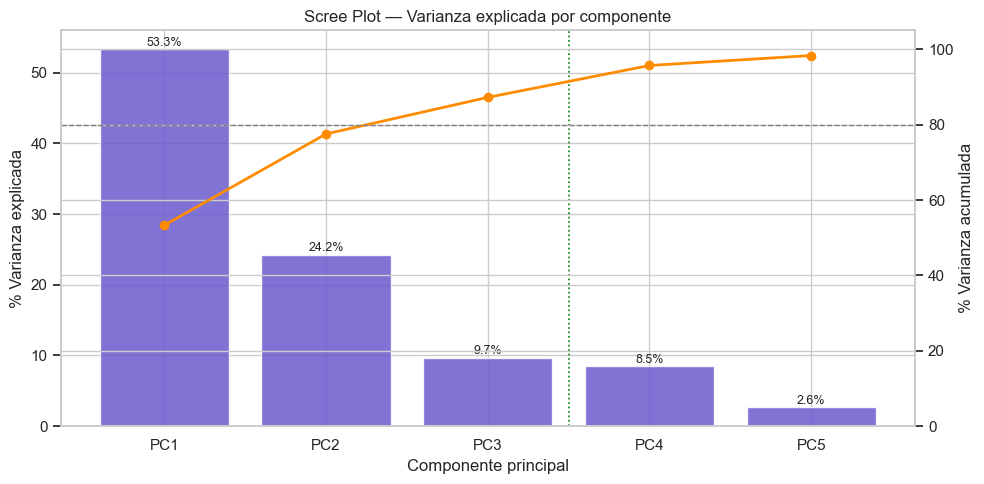

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
pca.scree_plot(ax=ax)
plt.tight_layout()
plt.show()

**Interpretación:**

- El primer componente (53.3%) concentra la mayor parte de la varianza, capturando la dimensión de tamaño y potencia del vehículo: autos con baterías grandes tienen simultáneamente más kW, más autonomía (km), más consumo (kWh/100 km) y más tiempo de carga.
- Las variables de consumo (kWh/100 km, Le/100 km) son altamente redundantes entre sus versiones CITY y HWY, lo que explica la alta concentración en pocos PCs.
- Se necesitan solo 3 componentes para superar el 80% de varianza acumulada, confirmando la alta colinealidad entre las métricas.

### Círculo de correlación

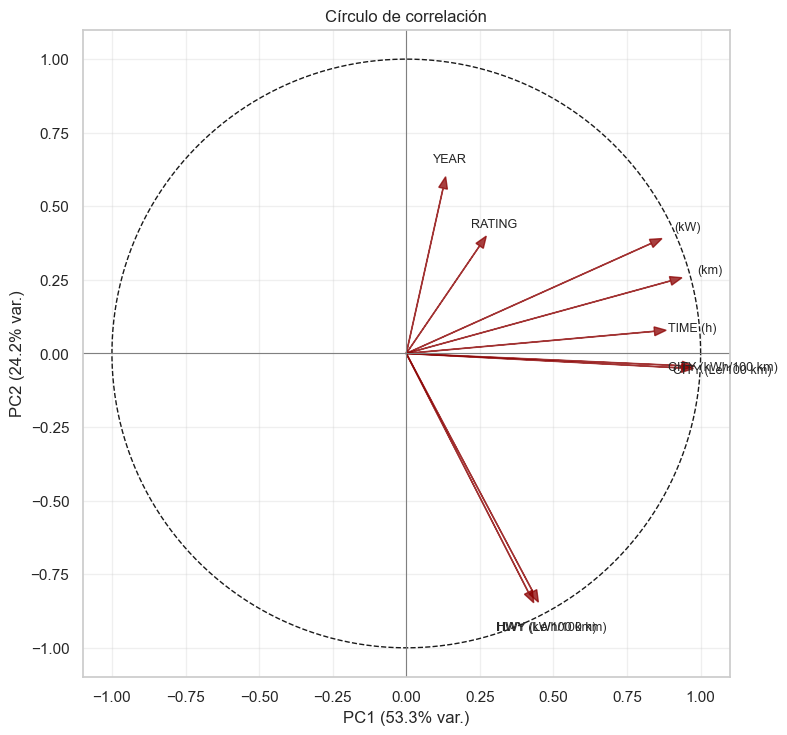

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
pca.circulo_correlacion(ax=ax)
plt.tight_layout()
plt.show()

**Interpretación:**

- Las variables `(kW)`, `(km)`, `CITY (kWh/100 km)`, `CITY (Le/100 km)` y `TIME (h)` apuntan todas hacia la derecha (positivas en PC1), indicando que potencia, autonomía, consumo y tiempo de carga están fuertemente correlacionados: un auto con batería grande tiene simultáneamente más rango, más consumo y más tiempo de carga.
- Las variables HWY (kWh/100 km y Le/100 km) apuntan hacia abajo (negativas en PC2), separándose del grupo CITY y definiendo el segundo eje.
- `YEAR` y `RATING` apuntan hacia arriba (PC2 positivo) y tienen poca proyección en PC1, indicando que el año del modelo y la calificación son mayormente independientes del eje potencia/consumo en este plano.
- `(kW)` tiene una dirección parcialmente independiente (componente en PC2), indicando que la potencia no correlaciona perfectamente con las demás variables de consumo.

### Plano principal (PC1 vs PC2)

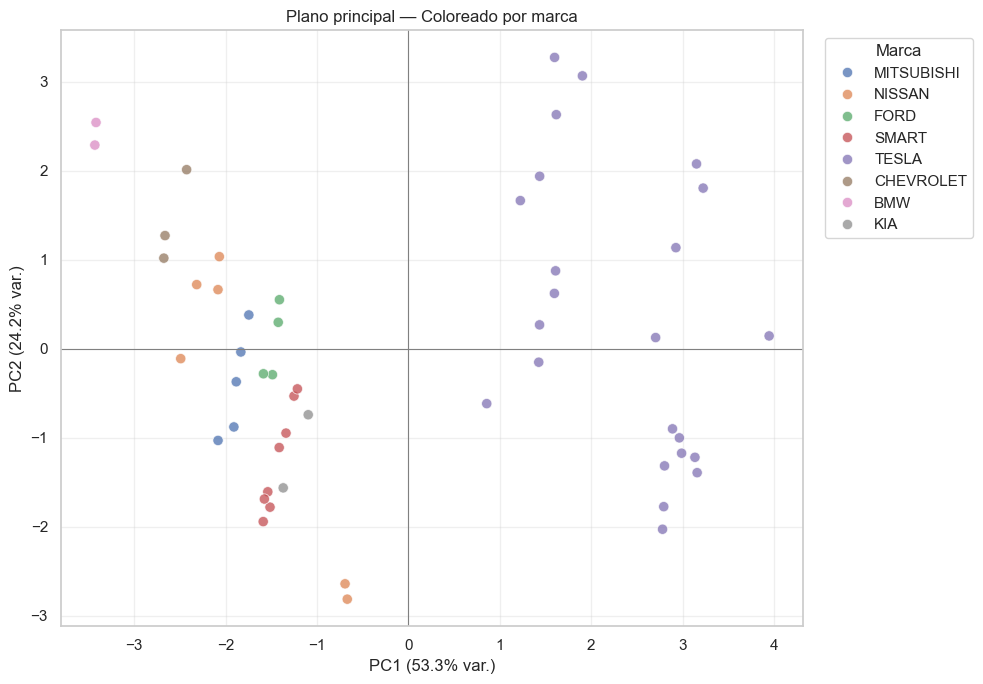

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
hue_brand = df_clean['Brand'].rename('Marca')
pca.plano_principal(hue=hue_brand, ax=ax)
ax.set_title('Plano principal — Coloreado por marca')
plt.tight_layout()
plt.show()

**Interpretación:**

- **Tesla** se ubica claramente a la derecha del plano (PC1 alto), reflejando sus altos valores de potencia, autonomía y consumo — son vehículos con baterías grandes y motores potentes.
- **BMW** (i3) aparece en el extremo izquierdo junto con marcas como Smart y Mitsubishi, correspondiendo a autos compactos con menor potencia, menor rango y menor consumo por km.
- **Nissan** (Leaf) y **Ford** (Focus Electric) se agrupan en la zona centro-izquierda, representando vehículos de rango medio.
- La separación por marca en PC1 valida que el PCA captura diferencias reales de tamaño/potencia entre fabricantes. PC2 introduce variabilidad adicional dentro de cada marca (variaciones entre modelos de distintos años).

### Biplot

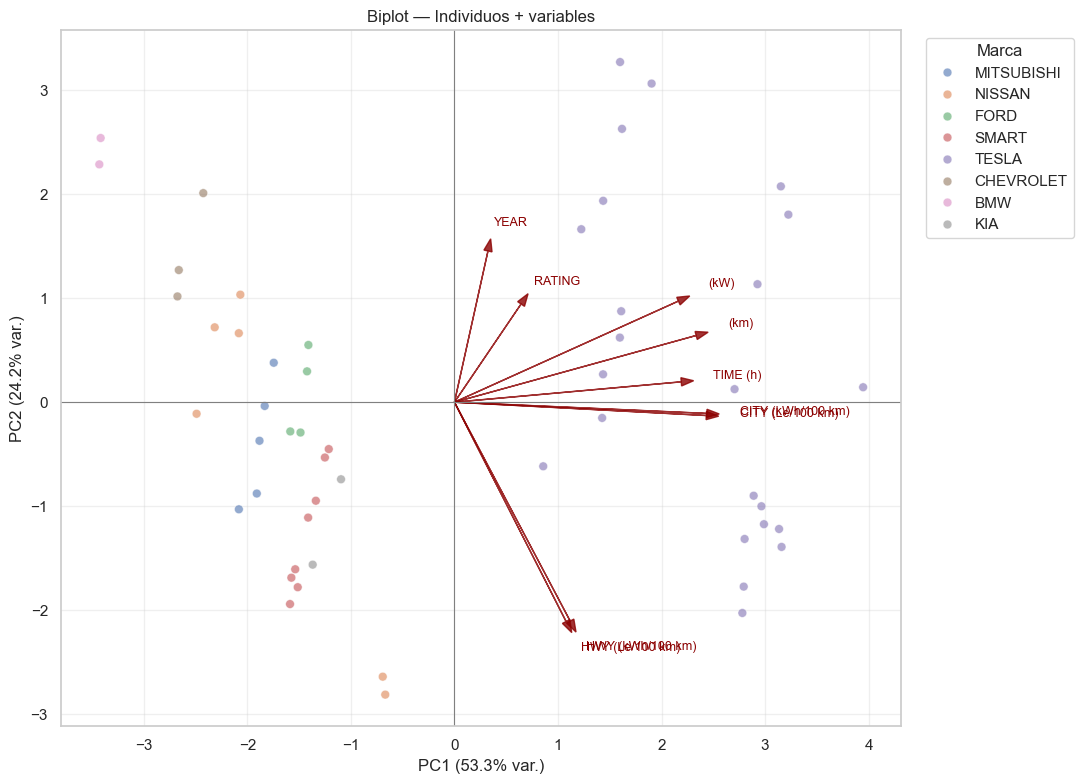

In [18]:
fig, ax = plt.subplots(figsize=(11, 8))
pca.biplot(hue=hue_brand, ax=ax)
ax.set_title('Biplot — Individuos + variables')
plt.tight_layout()
plt.show()

**Interpretación:**

- El biplot confirma que los vectores de `(kW)`, `(km)`, `CITY (kWh/100 km)` y `TIME (h)` apuntan hacia la derecha, exactamente donde se posicionan los Tesla — vehículos con baterías grandes que tienen simultáneamente alta potencia, gran autonomía, alto consumo por km y largo tiempo de carga.
- Los autos a la izquierda (BMW i3, Smart, Mitsubishi i-MiEV) están en la dirección opuesta a estos vectores, lo que confirma que son vehículos compactos y de bajo consumo absoluto.
- Los vectores HWY apuntan hacia abajo, explicando por qué algunos vehículos se separan verticalmente: aquellos con mayor diferencia entre consumo en carretera vs ciudad se desplazan hacia PC2 negativo.

---
## Tablas de contribuciones y correlaciones

In [19]:
print('Contribución de cada variable por componente (%):')
print(pca.contribuciones())
print()
print('Cos² de variables (calidad de representación):')
print(pca.cos2_variables())

Contribución de cada variable por componente (%):
                     PC1    PC2    PC3    PC4    PC5
variable                                            
YEAR                0.37  16.54   1.20  80.04   0.19
(kW)               15.72   6.99   0.01   0.37   6.18
CITY (kWh/100 km)  19.91   0.09   0.00   0.90   8.76
HWY (kWh/100 km)    4.20  32.75   1.45   8.34   1.65
CITY (Le/100 km)   19.83   0.12   0.00   0.83  10.85
HWY (Le/100 km)     3.91  32.90   2.75   8.35   0.40
RATING              1.54   7.29  86.69   0.02   3.81
(km)               18.28   3.04   2.52   0.81   0.05
TIME (h)           16.24   0.29   5.38   0.34  68.11

Cos² de variables (calidad de representación):
                      PC1     PC2     PC3     PC4     PC5
variable                                                 
YEAR               0.0179  0.3605  0.0105  0.6094  0.0005
(kW)               0.7544  0.1523  0.0001  0.0028  0.0147
CITY (kWh/100 km)  0.9554  0.0019  0.0000  0.0069  0.0209
HWY (kWh/100 km)   0.2014  0.

---
## Interpretación técnica

**Relación de variables:** En el círculo de correlación se observa que las variables de consumo CITY (kWh/100 km, Le/100 km), potencia (kW), autonomía (km) y tiempo de carga (h) apuntan todas en la misma dirección positiva de PC1. Esto refleja que en vehículos eléctricos, mayor autonomía implica baterías más grandes, lo que conlleva mayor consumo absoluto por km y mayor tiempo de carga. El eje PC1 captura esencialmente el "tamaño energético" del vehículo.

`YEAR` y `RATING` están mejor representados en PC2/PC4 (cos² de YEAR en PC4 = 0.61), por lo que su relación con las demás variables no es fácilmente interpretable en el plano PC1-PC2. La potencia (kW) comparte dirección con autonomía pero tiene una componente adicional en PC2 (cos² en PC2 = 0.15), sugiriendo que no toda la potencia se traduce linealmente en rango.